# 5. Nettoyage des données

In [1]:
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))
import json
from dotenv import load_dotenv
import time
import datetime 
from datetime import timedelta

import pandas as pd
import berserk

from src.cleaning_and_preprocessing.data_cleaning import *
from src.cleaning_and_preprocessing.preprocessing import *
from src.features.features_groups import *

## Etape 5.0

In [2]:
FINAL_DATASET_JSON_PATH = Path("../data/final/final_dataset.json")

df = pd.read_json(FINAL_DATASET_JSON_PATH)
df.shape
df.head()

,player_id,mean_ply_count,main_opening_white,main_opening_black,opening_diversity,opening_concentration,abandon_rate,time_loss_rate,draw_ratio,score_when_winstreak,...,weekday_bias,color_bias,session_length_performance_slope,within_session_performance_slope,games_per_day_performance_slope,games_per_week_performance_slope,elo_gain,elo_gain_per_game,elo_slope_per_game,elo_slope_per_day
0,a123krowy,41.511269,Queen’s Pawn Systems,King’s Pawn Games / Bishop’s Opening / Vienna,1.498863,0.444997,0.386714,0.021352,0.035587,0.536313,...,-0.028967,0.118548,0.006886,0.023772,0.003289,0.001328,-376,-0.446556,0.003464,0.297313
1,a5_tulatrain-moscow,47.283871,King’s Gambit,Sicilian,1.693547,0.498364,0.390323,0.038710,0.027419,0.347059,...,-0.053779,0.079765,0.023228,-0.071883,0.009776,0.001818,-133,-0.214863,-0.241720,-1.013004
2,abadan007,71.824885,Italian Game & Two Knights Defense,Italian Game & Two Knights Defense,2.434890,0.225493,0.036866,0.018433,0.032258,0.480000,...,-0.092144,-0.046084,-0.125320,0.307955,-0.030455,-0.001012,39,0.180556,0.151171,0.237955
3,abasssm,45.824742,King’s Pawn Games / Bishop’s Opening / Vienna,King’s Pawn Games / Bishop’s Opening / Vienna,2.261723,0.238830,0.274227,0.030928,0.014433,0.500000,...,-0.002235,0.102959,0.004610,0.026876,0.001997,0.000547,21,0.043388,0.166094,0.448836
4,abdeerrahim,63.962672,Italian Game & Two Knights Defense,Modern / Robatsch / Pirc,2.108971,0.359022,0.204322,0.041257,0.023576,0.568000,...,0.003827,0.017504,0.011173,0.011297,0.005349,-0.001877,136,0.267717,0.268417,0.892955


In [3]:
selected_features, missing_features = validate_features(df, SELECTED_CLUSTERING_FEATURES)
selected_features
missing_features

print(selected_features)
print(missing_features)

['mean_ply_count', 'opening_diversity', 'opening_concentration', 'draw_ratio', 'score_when_winstreak', 'score_when_losestreak', 'delay_ratio_when_winstreak', 'delay_ratio_when_losestreak', 'cv_games_per_day', 'cv_games_per_week', 'cv_games_interval', 'cv_sessions_interval', 'entropy_sessions_interval', 'mean_games_per_session', 'cv_games_per_session', 'weekday_bias', 'color_bias']
[]


## Etape 5A

In [4]:
uni_df = univariate_analysis(df, selected_features)
uni_df

,feature,nan_ratio,n_unique,variance,skew,q1,q3,iqr,min,max,decision,suggested_transform
0,color_bias,0.0,297,0.002622,0.235157,0.010707,0.079697,0.068989,-0.075147,0.195732,keep,NaN
1,cv_games_interval,0.0,298,7.613090,2.135251,2.431208,4.801777,2.370568,0.973216,17.779920,keep,log_or_robust_treatment
2,cv_games_per_day,0.0,298,0.025036,0.339217,0.684208,0.890931,0.206722,0.369694,1.272351,keep,NaN
3,cv_games_per_session,0.0,298,0.032628,0.842131,0.664673,0.879150,0.214478,0.314961,1.456002,keep,NaN
4,cv_games_per_week,0.0,298,0.060323,1.047746,0.580030,0.889726,0.309696,0.142544,2.080644,keep,log_or_robust_treatment
5,cv_sessions_interval,0.0,298,1.896145,1.611578,1.305642,2.723384,1.417742,0.810667,7.974402,keep,log_or_robust_treatment
6,delay_ratio_when_losestreak,0.0,298,0.273813,0.538779,0.817871,1.438986,0.621115,0.024258,3.062649,keep,NaN
7,delay_ratio_when_winstreak,0.0,298,0.233451,1.152187,0.552699,1.081068,0.528369,0.017159,3.132317,keep,log_or_robust_treatment
8,draw_ratio,0.0,282,0.000148,0.680919,0.016780,0.033068,0.016288,0.000000,0.068182,keep,NaN
9,entropy_sessions_interval,0.0,298,0.035681,-0.134449,0.964781,1.235405,0.270624,0.581918,1.512725,keep,NaN


### Discussion autour de chaque feature :
Pour chaque feature, on vérifie manuellement que :
- taux de NaN (stabilité)
    - drop si bcp de NaN
- la variance
    - drop si proche de 0
- les outliers
- skew
    - si > 1 : logtransformation potentielle

### Les 17 features :

'mean_ply_count'  : OK

'opening_diversity' : skew = -1.19 mais variable issue de l'entropie donc OK

'opening_concentration' : skew = 1.15 mais bornée sur [0,1] donc OK

'draw_ratio' : variance faible mais intertprétabilité méti

'score_when_winstreak' :  OK

'score_when_losestreak' : OK

'delay_ratio_when_winstreak' : skew = 1,15 => logtransformation

'delay_ratio_when_losestreak' : OK

'cv_games_interval' : skew = 2,13 => logtransformation

'cv_games_per_day' : OK

'cv_games_per_week' : skew = 1,04 => logtransformation

'cv_sessions_interval' : skew = 1,61 => logtransformation

'entropy_sessions_interval' : OK

'mean_games_per_session' : skew = 2,13 => logtransformation

'cv_games_per_session' : OK

'weekday_bias' : OK

'color_bias' : OK

## Etape 5B

In [5]:
targets = ["elo_slope_per_game"]

corr_prog_df = correlation_with_progression(df, selected_features, targets)
corr_summary_df = summarize_progression_correlations(corr_prog_df)

corr_summary_df

,feature,best_target,max_abs_pearson,max_abs_spearman,max_abs_corr
0,score_when_losestreak,elo_slope_per_game,0.446532,0.423238,0.446532
1,score_when_winstreak,elo_slope_per_game,0.435671,0.388555,0.435671
2,mean_ply_count,elo_slope_per_game,0.158365,0.175826,0.175826
3,draw_ratio,elo_slope_per_game,0.141872,0.174141,0.174141
4,cv_games_per_day,elo_slope_per_game,0.167613,0.155466,0.167613
5,entropy_sessions_interval,elo_slope_per_game,0.146834,0.125780,0.146834
6,delay_ratio_when_winstreak,elo_slope_per_game,0.125254,0.104051,0.125254
7,delay_ratio_when_losestreak,elo_slope_per_game,0.101756,0.059023,0.101756
8,cv_games_per_week,elo_slope_per_game,0.076922,0.042410,0.076922
9,mean_games_per_session,elo_slope_per_game,0.055593,0.014844,0.055593


### Discussion autour de chaque feature :
Pour chaque feature, on vérifie manuellement la corrélation max

### Les 17 features :

Corrélation forte (très informatives):
- score_when_losestreak : 0.446
- score_when_winstreak : 0,436

Corrélation moyenne (informatives) :
- draw_ratio
- mean_ply_count
- cv_games_per_day
- entropy_sessions_interval
- delay_ratio_when_winstreak : 0.12
- delay_ratio_when_losestreak : 0.1

Corrélation faible (peu informatives mais potentiellement utiles pour clustering) : tout le reste

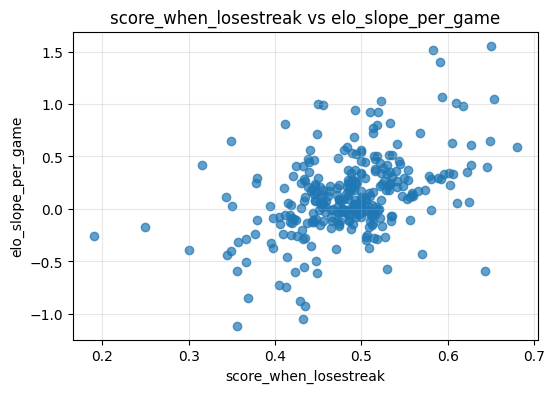

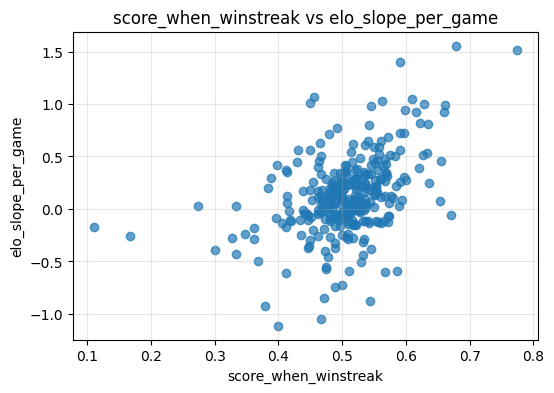

In [6]:
top_features = corr_summary_df["feature"].head(2).tolist()

for f in top_features:
    plot_feature_vs_target(df, f, "elo_slope_per_game")

## Etape 5C

In [7]:
corr_pairs_df = find_correlated_pairs(df, selected_features, threshold=0.7)
corr_pairs_df

,feature_1,feature_2,correlation,abs_correlation
0,opening_diversity,opening_concentration,-0.927788,0.927788
1,cv_games_interval,cv_sessions_interval,0.844694,0.844694


In [8]:
corr_pairs_df["suggested_drop"] = corr_pairs_df.apply(
    lambda row: choose_feature_to_drop(row, uni_df, corr_summary_df),
    axis=1
)
corr_pairs_df

,feature_1,feature_2,correlation,abs_correlation,suggested_drop
0,opening_diversity,opening_concentration,-0.927788,0.927788,opening_concentration
1,cv_games_interval,cv_sessions_interval,0.844694,0.844694,cv_sessions_interval


In [42]:
corr_pairs_dfe = find_correlated_pairs(df, selected_features, threshold=0.3)
corr_pairs_dfe
corr_pairs_dfe["suggested_drop"] = corr_pairs_dfe.apply(
    lambda row: choose_feature_to_drop(row, uni_df, corr_summary_df),
    axis=1
)
corr_pairs_dfe

,feature_1,feature_2,correlation,abs_correlation,suggested_drop
0,opening_diversity,opening_concentration,-0.927788,0.927788,opening_concentration
1,cv_games_interval,cv_sessions_interval,0.844694,0.844694,cv_sessions_interval
2,cv_games_per_day,cv_games_per_session,0.621987,0.621987,cv_games_per_session
3,cv_games_per_day,cv_games_per_week,0.610518,0.610518,cv_games_per_week
4,cv_games_interval,mean_games_per_session,0.523464,0.523464,cv_games_interval
5,mean_games_per_session,cv_games_per_session,0.503649,0.503649,cv_games_per_session
6,delay_ratio_when_winstreak,delay_ratio_when_losestreak,-0.488342,0.488342,delay_ratio_when_losestreak
7,cv_games_per_week,cv_games_interval,0.456696,0.456696,cv_games_interval
8,cv_games_per_week,cv_sessions_interval,0.434556,0.434556,cv_sessions_interval
9,cv_games_per_day,entropy_sessions_interval,0.420558,0.420558,entropy_sessions_interval


### Discussion autour de chaque feature :
Pour chaque pair trop corrélée, ne garder qu'une feature entre les 2

### Les 17 features :

opening_diversity vs opening_concentration : drop de opening_concentration car fortement redondante et moins interprétable

cv_games_interval vs cv_sessions_interval : drop de cv_sessions_interval car fortement redondante et moins interprétable


## Etape 5D

Sur les 17 features candidates :
- 12 sont conservées
- 3 doivent être log-transformées 
- 2 sont écartées car corrélées avec d'autres features plus pertinentes

In [19]:
features_to_keep = [
    'mean_ply_count',
    'opening_diversity',
    'draw_ratio',
    'score_when_winstreak',
    'score_when_losestreak',
    'delay_ratio_when_winstreak', # On ne la logtransforme par finalement car les tests de l'étape 6 montrent que c'est pas si urgent
    'delay_ratio_when_losestreak',
    'cv_games_per_day',
    'entropy_sessions_interval',
    'cv_games_per_session',
    'weekday_bias',
    'color_bias'
]

features_to_transform = [
    'cv_games_interval',
    'mean_games_per_session',

    'cv_games_per_week'
]

features_to_drop_univariate = []

features_to_drop_corr = [
    'opening_concentration',
    'cv_sessions_interval'
]

In [22]:
selected_feature_cols = [
    f for f in selected_features
    if f not in features_to_drop_univariate
    and f not in features_to_drop_corr
]
selected_feature_cols

['mean_ply_count',
 'opening_diversity',
 'draw_ratio',
 'score_when_winstreak',
 'score_when_losestreak',
 'delay_ratio_when_winstreak',
 'delay_ratio_when_losestreak',
 'cv_games_per_day',
 'cv_games_per_week',
 'cv_games_interval',
 'entropy_sessions_interval',
 'mean_games_per_session',
 'cv_games_per_session',
 'weekday_bias',
 'color_bias']

In [23]:
FEATURE_GROUPS_UPDATED = {
    group: [f for f in feats if f in selected_feature_cols]
    for group, feats in FEATURE_GROUPS.items()
}
FEATURE_GROUPS_UPDATED

{'style': ['mean_ply_count', 'opening_diversity'],
 'endgame': ['draw_ratio'],
 'streaks': ['score_when_winstreak',
  'score_when_losestreak',
  'delay_ratio_when_winstreak',
  'delay_ratio_when_losestreak'],
 'global_rhythm': ['cv_games_per_day',
  'cv_games_per_week',
  'cv_games_interval'],
 'sessions': ['entropy_sessions_interval',
  'mean_games_per_session',
  'cv_games_per_session'],
 'context': ['weekday_bias', 'color_bias']}

In [24]:
summary = build_step5_summary(
    selected_features=selected_feature_cols,
    dropped_features=features_to_drop_univariate + features_to_drop_corr,
    log_features=features_to_transform,
)

summary

{'selected_feature_cols': ['mean_ply_count',
  'opening_diversity',
  'draw_ratio',
  'score_when_winstreak',
  'score_when_losestreak',
  'delay_ratio_when_winstreak',
  'delay_ratio_when_losestreak',
  'cv_games_per_day',
  'cv_games_per_week',
  'cv_games_interval',
  'entropy_sessions_interval',
  'mean_games_per_session',
  'cv_games_per_session',
  'weekday_bias',
  'color_bias'],
 'dropped_features': ['opening_concentration', 'cv_sessions_interval'],
 'features_to_log': ['cv_games_interval',
  'mean_games_per_session',
  'cv_games_per_week']}

# 6. Prétraitement des données

Dans cette partie, il faudra :
- Sélectionner les features finales
- Gérer les NaN (sachant que mes données n'en contiennent pas c'est facile)
- Logtransforer certaines features
- Scaling (robustscaler)

## Étape 6.1

In [25]:
X = build_clustering_matrix(df, selected_feature_cols)
X.shape
X.head()

,mean_ply_count,opening_diversity,draw_ratio,score_when_winstreak,score_when_losestreak,delay_ratio_when_winstreak,delay_ratio_when_losestreak,cv_games_per_day,cv_games_per_week,cv_games_interval,entropy_sessions_interval,mean_games_per_session,cv_games_per_session,weekday_bias,color_bias
0,41.511269,1.498863,0.035587,0.536313,0.430131,0.859893,1.046801,0.841911,0.815609,4.555823,1.218249,5.078313,0.909771,-0.028967,0.118548
1,47.283871,1.693547,0.027419,0.347059,0.377358,0.804647,1.084522,0.962273,0.729995,2.853472,1.141608,2.695652,0.912212,-0.053779,0.079765
2,71.824885,2.434890,0.032258,0.480000,0.558824,0.996008,0.649151,0.907368,1.033479,2.366006,1.313033,1.486301,0.592560,-0.092144,-0.046084
3,45.824742,2.261723,0.014433,0.500000,0.486607,0.918316,0.819637,0.811436,0.600010,3.478529,1.294544,3.368056,0.827018,-0.002235,0.102959
4,63.962672,2.108971,0.023576,0.568000,0.434426,0.629226,0.721440,0.788596,1.063773,4.503286,1.078820,2.203463,0.811527,0.003827,0.017504


## Étape 6.2

In [26]:
X_imputed, imputer = impute_missing_values(X, strategy="median")
X_imputed.isna().sum()

mean_ply_count                 0
opening_diversity              0
draw_ratio                     0
score_when_winstreak           0
score_when_losestreak          0
delay_ratio_when_winstreak     0
delay_ratio_when_losestreak    0
cv_games_per_day               0
cv_games_per_week              0
cv_games_interval              0
entropy_sessions_interval      0
mean_games_per_session         0
cv_games_per_session           0
weekday_bias                   0
color_bias                     0
dtype: int64

## Étape 6.3

In [27]:
X_transformed = apply_log_transformations(
    X_imputed,
    features_to_transform=features_to_transform,
)
X_transformed.head()

,mean_ply_count,opening_diversity,draw_ratio,score_when_winstreak,score_when_losestreak,delay_ratio_when_winstreak,delay_ratio_when_losestreak,cv_games_per_day,cv_games_per_week,cv_games_interval,entropy_sessions_interval,mean_games_per_session,cv_games_per_session,weekday_bias,color_bias
0,41.511269,1.498863,0.035587,0.536313,0.430131,0.859893,1.046801,0.841911,0.596421,1.714847,1.218249,1.804727,0.909771,-0.028967,0.118548
1,47.283871,1.693547,0.027419,0.347059,0.377358,0.804647,1.084522,0.962273,0.548118,1.348975,1.141608,1.307157,0.912212,-0.053779,0.079765
2,71.824885,2.434890,0.032258,0.480000,0.558824,0.996008,0.649151,0.907368,0.709748,1.213727,1.313033,0.910796,0.592560,-0.092144,-0.046084
3,45.824742,2.261723,0.014433,0.500000,0.486607,0.918316,0.819637,0.811436,0.470010,1.499295,1.294544,1.474318,0.827018,-0.002235,0.102959
4,63.962672,2.108971,0.023576,0.568000,0.434426,0.629226,0.721440,0.788596,0.724536,1.705345,1.078820,1.164232,0.811527,0.003827,0.017504


In [28]:
skew_check_df = check_post_transform_skew(
    X_before=X_imputed,
    X_after=X_transformed,
    features=features_to_transform,
)

skew_check_df

,feature,skew_before,skew_after
0,cv_games_interval,2.135251,0.883862
1,cv_games_per_week,1.047746,0.355507
2,mean_games_per_session,2.129561,0.980137


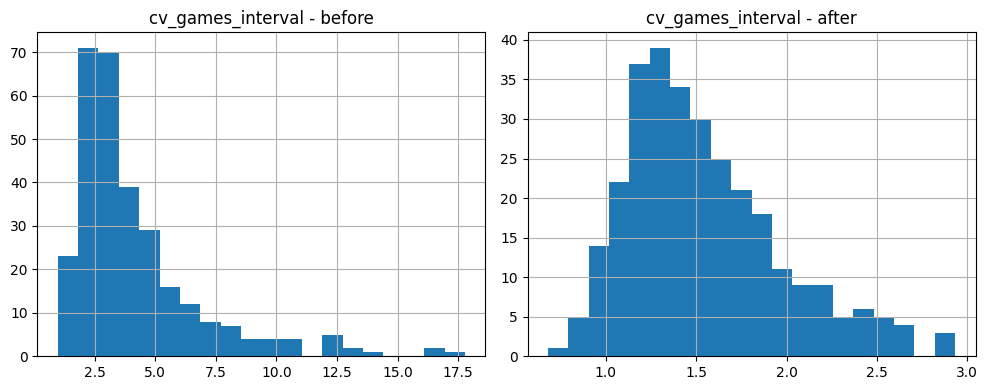

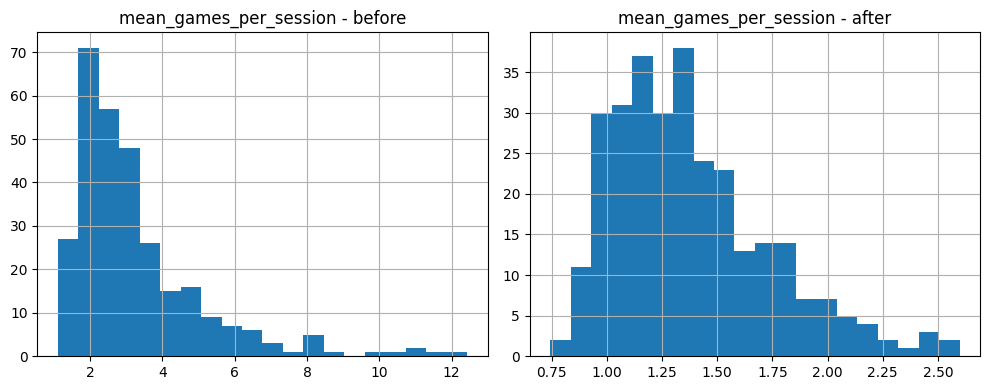

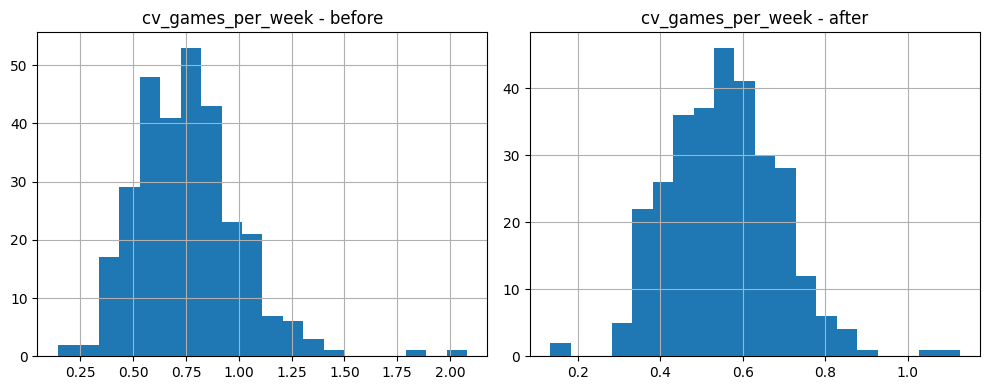

In [29]:
for feature in features_to_transform:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    X_imputed[feature].hist(ax=axes[0], bins=20)
    axes[0].set_title(f"{feature} - before")

    X_transformed[feature].hist(ax=axes[1], bins=20)
    axes[1].set_title(f"{feature} - after")

    plt.tight_layout()
    plt.show()

## Étape 6.4

Scaling avec RobustScaler pour résister aux outliers

In [30]:
X_scaled, scaler = scale_features(X_transformed)
X_scaled.head()

,mean_ply_count,opening_diversity,draw_ratio,score_when_winstreak,score_when_losestreak,delay_ratio_when_winstreak,delay_ratio_when_losestreak,cv_games_per_day,cv_games_per_week,cv_games_interval,entropy_sessions_interval,mean_games_per_session,cv_games_per_session,weekday_bias,color_bias
0,-1.634128,-1.487510,0.701653,0.386847,-0.790694,0.082496,-0.137330,0.281429,0.238232,0.503156,0.442384,1.066812,0.633159,-0.383378,1.056363
1,-1.083248,-1.055074,0.200179,-2.365164,-1.503167,-0.022063,-0.076599,0.863668,-0.031632,-0.193409,0.159186,-0.038154,0.644538,-0.714865,0.494206
2,1.258703,0.591611,0.497257,-0.432019,0.946763,0.340110,-0.777550,0.598068,0.871385,-0.450901,0.792627,-0.918362,-0.845833,-1.227418,-1.329976
3,-1.222493,0.206968,-0.597136,-0.141192,-0.028219,0.193068,-0.503066,0.134010,-0.468019,0.092778,0.724307,0.333064,0.247324,-0.026253,0.830394
4,0.508411,-0.132326,-0.035811,0.847621,-0.732705,-0.354068,-0.661163,0.023523,0.954004,0.485067,-0.072829,-0.355550,0.175098,0.054733,-0.408264


In [31]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_ply_count,298.0,0.018303,0.676399,-1.634128,-0.500298,3.391384e-16,0.499702,1.796482
opening_diversity,298.0,-0.206776,0.901086,-3.707561,-0.578902,0.000000e+00,0.421098,1.266943
draw_ratio,298.0,0.088047,0.747507,-1.483267,-0.453018,-1.066855e-16,0.546982,2.702841
score_when_winstreak,298.0,-0.041293,1.022454,-5.796165,-0.490082,0.000000e+00,0.509918,3.845956
score_when_losestreak,298.0,-0.044967,0.896111,-4.023245,-0.574373,0.000000e+00,0.425627,2.582746
delay_ratio_when_winstreak,298.0,0.107480,0.914451,-1.512475,-0.498904,1.051676e-16,0.501096,4.383323
delay_ratio_when_losestreak,298.0,0.038964,0.842472,-1.783633,-0.505909,0.000000e+00,0.494091,3.108202
cv_games_per_day,298.0,0.015413,0.765410,-2.002878,-0.481444,-2.680148e-16,0.518556,2.363642
cv_games_per_week,298.0,0.000077,0.754879,-2.349443,-0.538229,0.000000e+00,0.461771,3.192154
cv_games_interval,298.0,0.175526,0.814899,-1.467675,-0.414375,2.114194e-16,0.585625,2.821935


On constate que la standardisation est efficace :
- mean est en general proche de 0
- median est extrement proche de 0
- IQR pertinents (25% proche de -0.5, 75% proche de 0.5)
- std proche de 1 (0.7 dans les pires cas)

Il y a toujours des outliers quand on regarde min et max mais leur influence est réduite

In [33]:
summary_preprocessing = summarize_preprocessing(
    X=X,
    X_imputed=X_imputed,
    X_transformed=X_transformed,
    X_scaled=X_scaled,
    selected_feature_cols=selected_feature_cols,
    features_to_transform=features_to_transform,
)

summary_preprocessing

{'n_samples': 298,
 'n_features': 15,
 'selected_feature_cols': ['mean_ply_count',
  'opening_diversity',
  'draw_ratio',
  'score_when_winstreak',
  'score_when_losestreak',
  'delay_ratio_when_winstreak',
  'delay_ratio_when_losestreak',
  'cv_games_per_day',
  'cv_games_per_week',
  'cv_games_interval',
  'entropy_sessions_interval',
  'mean_games_per_session',
  'cv_games_per_session',
  'weekday_bias',
  'color_bias'],
 'features_to_transform': ['cv_games_interval',
  'mean_games_per_session',
  'cv_games_per_week'],
 'initial_nan_count': 0,
 'post_imputation_nan_count': 0,
 'post_transformation_nan_count': 0,
 'post_scaling_nan_count': 0}

In [34]:
FEATURE_GROUPS_UPDATED = {
    group: [f for f in feats if f in selected_feature_cols]
    for group, feats in FEATURE_GROUPS.items()
}

FEATURE_GROUPS_UPDATED  

{'style': ['mean_ply_count', 'opening_diversity'],
 'endgame': ['draw_ratio'],
 'streaks': ['score_when_winstreak',
  'score_when_losestreak',
  'delay_ratio_when_winstreak',
  'delay_ratio_when_losestreak'],
 'global_rhythm': ['cv_games_per_day',
  'cv_games_per_week',
  'cv_games_interval'],
 'sessions': ['entropy_sessions_interval',
  'mean_games_per_session',
  'cv_games_per_session'],
 'context': ['weekday_bias', 'color_bias']}

In [40]:
FINAL_DATASET_RAW_JSON_PATH = Path("../data/final_scaled/X_raw_clustering.parquet")
FINAL_DATASET_TRANSFORMED_JSON_PATH = Path("../data/final_scaled/X_transformed.parquet")
FINAL_DATASET_SCALED_JSON_PATH = Path("../data/final_scaled/X_scaled.parquet")


X.to_parquet(FINAL_DATASET_RAW_JSON_PATH)
X_transformed.to_parquet(FINAL_DATASET_TRANSFORMED_JSON_PATH)
X_scaled.to_parquet(FINAL_DATASET_SCALED_JSON_PATH)

In [36]:
print("X shape:", X.shape)
print("X_transformed shape:", X_transformed.shape)
print("X_scaled shape:", X_scaled.shape)

X shape: (298, 15)
X_transformed shape: (298, 15)
X_scaled shape: (298, 15)


Usage de X_scaled pour la suite